# Group Project 2: Data Structures in Action Table of Contents & Text Analysis


**Authors:** Mike Beitner, Chris Taylor, Luis Echeverry

**Sources**
- DS/ML Book: *Math for Deep Learning - Ronald T. Kneusel*
    - Link: (https://a.co/d/02MiYbto)
- Public Domain Novel: *The Brothers Karamazov - Fyodor Dostoevsky (tr. Constance Garnett)*
    - Link: (https://www.gutenberg.org/files/28054/28054-0.txt)

---

## Project Overview




This project involved analyzing large text datasets using various data structures and algorithms. We extracted our text datasets from two seperate sources: a DS/ML book & a public domain novel. Using these seperate text sources we were tasked with creating a hierarchical Table of Contents for our DS/ML book & conducting a letter & word analysis for our public domain novel with the only constraint being no use of NLP libraries

The Project is organized into different sections:
- **Question 1**
    - Builds a hierarchical tree from a DS/AI/ML book's Table of Contents using pure Python. Implements insert(), print_toc() in three modes, depth(), and height().
- **Question 2**
    - Analyzes a public-domain novel from Project Gutenberg across two workstreams:
        - **Data Processing:** Preprocessing pipeline, letter/word frequency, n-grams, and sentence metrics
        - **Visualizations & Insights:** Visualizations that include bar plots, word clouds, and tables. Also including a Big-O algorithmic complexity analysis for our work.




---

## Setup & Imports

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

# Test Library
import pytest

# CORE DATA STRUCTURES
from tree import TableOfContentsNode, TableOfContents

# Natural Language Processing Utilities
import nltk
nltk.download('stopwords', quiet=True)

# CORE TEXT PROCESSING UTILITIES
import re
import string
import math
import collections
from collections import Counter
import itertools

# ORGANIZES TEXT DATA, METADATA, AND DERIVED FEATURES FOR STRUCTURED ANALYSIS
import pandas as pd

# EXPLORATORY DATA ANALYSIS AND VISUALIZATION
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# NLP VISUALIZATION + PREPROCESSING COMPONENTS
from wordcloud import WordCloud
from nltk.corpus import stopwords

print('All imports successful.')

All imports successful.


## Q1. Build a Table of Contents (Tree)


### Tree Structure

We decided to implement a single `TableOfContentsNode` class & a `TableOfContents` class which constructs the hierarchical table of contents for our DS/ML book *Math for Deep Learning by Ronald T. Kneusel*


**TableOfContentsNode**
| Attribute | Type | Description |
|---|---|---|
| `title` | `str` | Displays name of chapter or section in string format |
| `children` | `list` | Dynamic array containing the child `TableOfContentsNode` objects |


**TableOfContents**
| Attribute | Type | Description |
|---|---|---|
| `root` | `TableOfContentsNode` | Root node representing book title |
| `source_url` | `str` | string containing url link of ds/ml book |

**Supported Operations & Theoretical Complexities**

| Operation | Complexity | Description |
|---|---|---|
| `add_child(parent, child)` | O(1) | Appends node to child list, since we are only adding to list, its time complexity runs in constant time. |
| `insert(path, title)` | O(D) | Traverses the tree level by level (depth).|
| `print_toc(mode)` | O(N) |Since this is a pre-order traversal, it must traverse through all nodes once. |
| `dfs_traverse(node, mode, indices, level )` | O(N) |Visits current node and its descendants recursively. Since it has to travel each node it is O(n).|
| `find_node(current, title)` | O(N) Worst | Must visit node until it is found, worst case is when node is the last node of the tree.|
| `get_height(node)` | O(N) | Recursively evaluates all children from the tree to calculate height  |
| `get_depth(target_title, node=None, depth=0)` | O(N) Worst | Recursively searches for target_title while incrementing the depth counter, worst case would have to search each node. |


Design Note: Our design option allows us to add as many child nodes (sub-sections) since we are using an N-array tree instead of a binary tree which at most can hold two child nodes.

In [2]:
# DEMONSTRATING TableOfContents
source = "https://cbwilp-artefacts.s3.ap-south-1.amazonaws.com/AIML/SEM2/FREE_BOOKS/Ronald_T_Kneusel_Math_for_Deep_Learning_What_You_Need_to_Know_to.pdf"
book = TableOfContents("Math For Deep Learning", source)

# INSERT
book.insert([1], "SETTING THE STAGE")
book.insert([1, 1], "Installing the Toolkits")
book.insert([1, 1, 1], "Linux")
book.insert([1, 1, 2], "macOS")
book.insert([1, 1, 3], "Windows")
book.insert([1, 2], "NumPy")
book.insert([1, 2, 1], "Defining Arrays")
book.insert([1, 2, 2], "Data Types")

# PRINT TOC
book.print_toc(mode="indented_numbered")


# FIND NODE
NodeFound = book.find_node(book.root, "macOS")
if NodeFound:
    print(f"Node Found: {NodeFound}")
else:
    print("Not found")

NodeFound = book.find_node(book.root, "Chapter Not in book")
if NodeFound:
    print(f"Node Found: {NodeFound}")
else:
    print("Not found")


# GET HEIGHT
bookHeight = book.get_height(book.root)
print(f"The height from the root of our table of contents is: {bookHeight}")


# GET DEPTH
bookDepth = book.get_depth("Data Types")
print(f"The depth from chapter Data Types is: {bookDepth}")

Source: https://cbwilp-artefacts.s3.ap-south-1.amazonaws.com/AIML/SEM2/FREE_BOOKS/Ronald_T_Kneusel_Math_for_Deep_Learning_What_You_Need_to_Know_to.pdf

  - SETTING THE STAGE
    - Installing the Toolkits
      - Linux
      - macOS
      - Windows
    - NumPy
      - Defining Arrays
      - Data Types
Node Found: macOS
Not found
The height from the root of our table of contents is: 3
The depth from chapter Data Types is: 3


### Traversal Method

For our traversal method we decided to use a depth-first search (DFS). We use a pre-order DFS which prints the parent chapter first, then recursively visits each child node to print its sections.

- **Why Not BFS?**
    
    If we used a breadth-first search traversal we wouldn't be able to get the hierarchical table of contents structure due to its level order traversal. It would print all the chapters first, then all of the sections.

To be able to get the following format:
```
Title
    - chapter
        - subchapter
            - sub-subchapter
```
We created an indent variable that multiplied a space `str` by the level of the node, allowing for deeper level sections to be automatically indented.

### Insertion Strategy
The strategy for our `insert(path,title)` method, involved creating a path [1, 2, 1] which represents Chapter 1, Section 2, Subsection 1. This allows our tree structure to insert subsections with feasibility.

In the case where certain chapters or sections are skipped, our insertion method utilizes a while loop to generate placeholders to prevent an `IndexError` from occuring.


### Hierarchical Table of Contents
**(INCLUDE FULL TABLE OF CONTENTS WHEN DONE)**

In [3]:
# Demonstrating the TOC Structure
source = "https://cbwilp-artefacts.s3.ap-south-1.amazonaws.com/AIML/SEM2/FREE_BOOKS/Ronald_T_Kneusel_Math_for_Deep_Learning_What_You_Need_to_Know_to.pdf"
book = TableOfContents("Math for Deep Learning", source)

book.insert([1], "SETTING THE STAGE")
book.insert([1, 1], "Installing the Toolkits")
book.insert([1, 1, 1], "Linux")
book.insert([1, 1, 2], "macOS")
book.insert([1, 1, 3], "Windows")
book.insert([1, 2], "NumPy")
book.insert([1, 2, 1], "Defining Arrays")
book.insert([1, 2, 2], "Data Types")

book.insert([2], "PROBABILITY")
book.insert([2, 1], "Basic Concepts")
book.insert([2, 1, 1], "Sample Space and Events")
book.insert([2, 1, 2], "Random Variables")
book.insert([2, 2], "The Rules of Probability")
book.insert([2, 2, 1], "Probability of an Event")


print("--- FULL TOC (INDENTED NUMBERED) ---")
book.print_toc(mode="indented_numbered")

--- FULL TOC (INDENTED NUMBERED) ---
Source: https://cbwilp-artefacts.s3.ap-south-1.amazonaws.com/AIML/SEM2/FREE_BOOKS/Ronald_T_Kneusel_Math_for_Deep_Learning_What_You_Need_to_Know_to.pdf

  - SETTING THE STAGE
    - Installing the Toolkits
      - Linux
      - macOS
      - Windows
    - NumPy
      - Defining Arrays
      - Data Types
  - PROBABILITY
    - Basic Concepts
      - Sample Space and Events
      - Random Variables
    - The Rules of Probability
      - Probability of an Event


## Q2. Letters & Words Analysis

For this section of the assignment we decided to conduct our letters & word analysis on the book *The Brothers Karamazov by Fyodor Dostoevsky (tr. Constance Garnett)*

### Preprocessing & Counting


Since we were restricted from using NLP libraries, we conducted our preprocessing pipeline in four steps, in order to prepare the raw text for an accurate frequency analysis. Our pipeline, is designed to clean the raw text in order to limit noise that introduces bias, and instead allows the raw text to be suitable for conducting analysis.

1. `toLower(text)`

**Description:** Converts all characters in the text to lowercase.


2. `removePunctuation(text, keepApostrophes=True)`

**Description:** Removes punctuation, digits and special characters from the text. By default, preserves apostrophes that appear between two lowercase letters.

3. `tokenize(text)`

**Description:** Splits clean text on whitespace and filters out tokens that are a single character or empty.

4. `removeStopwords(tokens, stopwordSet=STOPWORDS)`

**Description:** Filters a token list by removing any token present in the provided stopword set.




**Why?**

- `toLower()`
    - This function helps prevent artificial duplication of tokens and is standard practice in NLP preprocessing pipelines.
- `removePunctuation()`
    - Helps eliminate noise that does not contribute to semantic analysis. Also standardizes input for tokenization
- `tokenize()`
    - Removes low-information tokens that add noise. Additionally reduces dimenstionality of token space.
- `removeStopwords()`
    - Removes high-frequency, low information words. Improves the signal-to-noise ratio in the analysis. Is essential for both the word frequency and wordcloud methods. 


**Preprocessing Pipeline Theoretical Complexities**

| Preprocessing Pipeline | Complexity | Description |
|---|---|---|
| `toLower(text)` | O(N) | Single pass over all characters |
| `removePunctuation(text)` | O(N) | Scans each character once.|
| `tokenize(text)` | O(N) |This is a single linear scan. |
| `removeStopwords(tokens)` | O(W) |Set lookup is O(1) per token.|
| `Full Pipeline` | O(N) |Dominated by character level passes.|


**Counting Theoretical Complexities**

| Preprocessing Pipeline | Complexity | Description |
|---|---|---|
| `computeLetterFreqs(text)` | O(N) | Single pass over all characters. |
| `computeWordFreqs(tokens)` | O(W) | Single pass over token list.|
| `Counter.most_common(k)` | O(WlogW) |Heapq-based partial sort internally. |

### Interpretation of Distributions (letters), Themes (words), and Phrase Patterns (n-grams)

- **Letter Distributions**

We used a method named `computeLetterFreqs(text)` in order to calculate the most frequent letter from *Dostoevsky's* text. From this method we were able to find that the most frequent letter from the text was the letter "e". The letter "e" appeared 178,128 times, which was 11.94% of the total letter count, making it the most frequent letter by far in the text. It was followed by letters "t" and "a" which appeared 137,809 & 122,042 times respectively. 

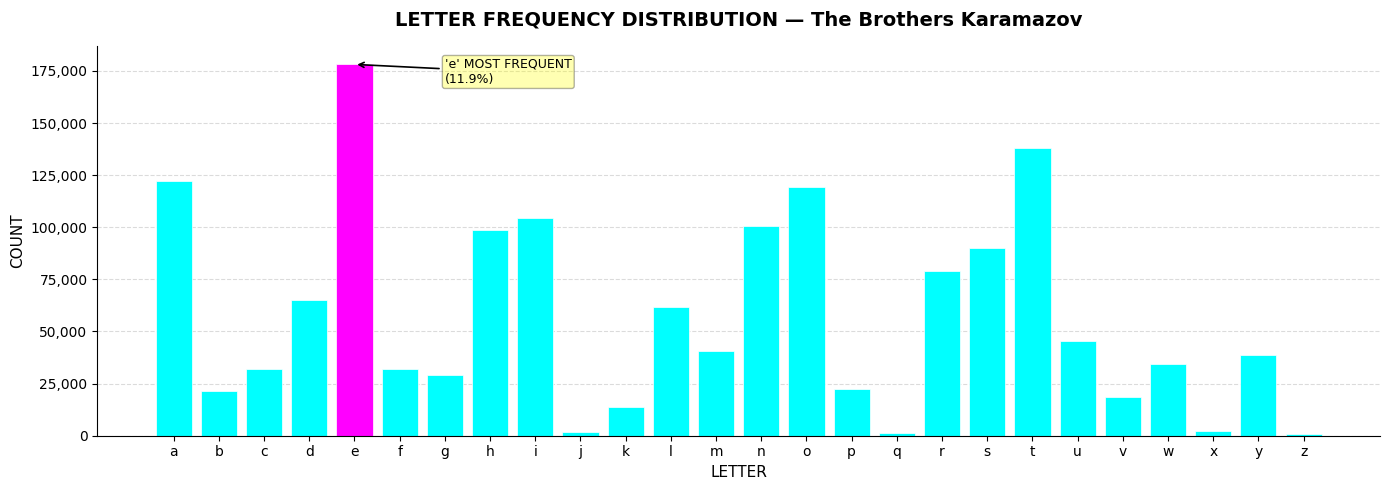


- **Themes (Words)**

Our method `computeWordFreqs(tokens)` was used to compute the frequency of words from *Dostoevsky's novel*. The most frequent word from the novel was the word "one" occuring 1,604 times for over 1.013 % of the total words from the novel. Other common words involved the main characters "Alyosha" (1,245 times), "Mitya(923 times), "Ivan"(718 times), and "Father"(820 times). These word counts, coincide with the theme of the book which explored the dysfunctionality of the family from *The Brothers Karamazov*.



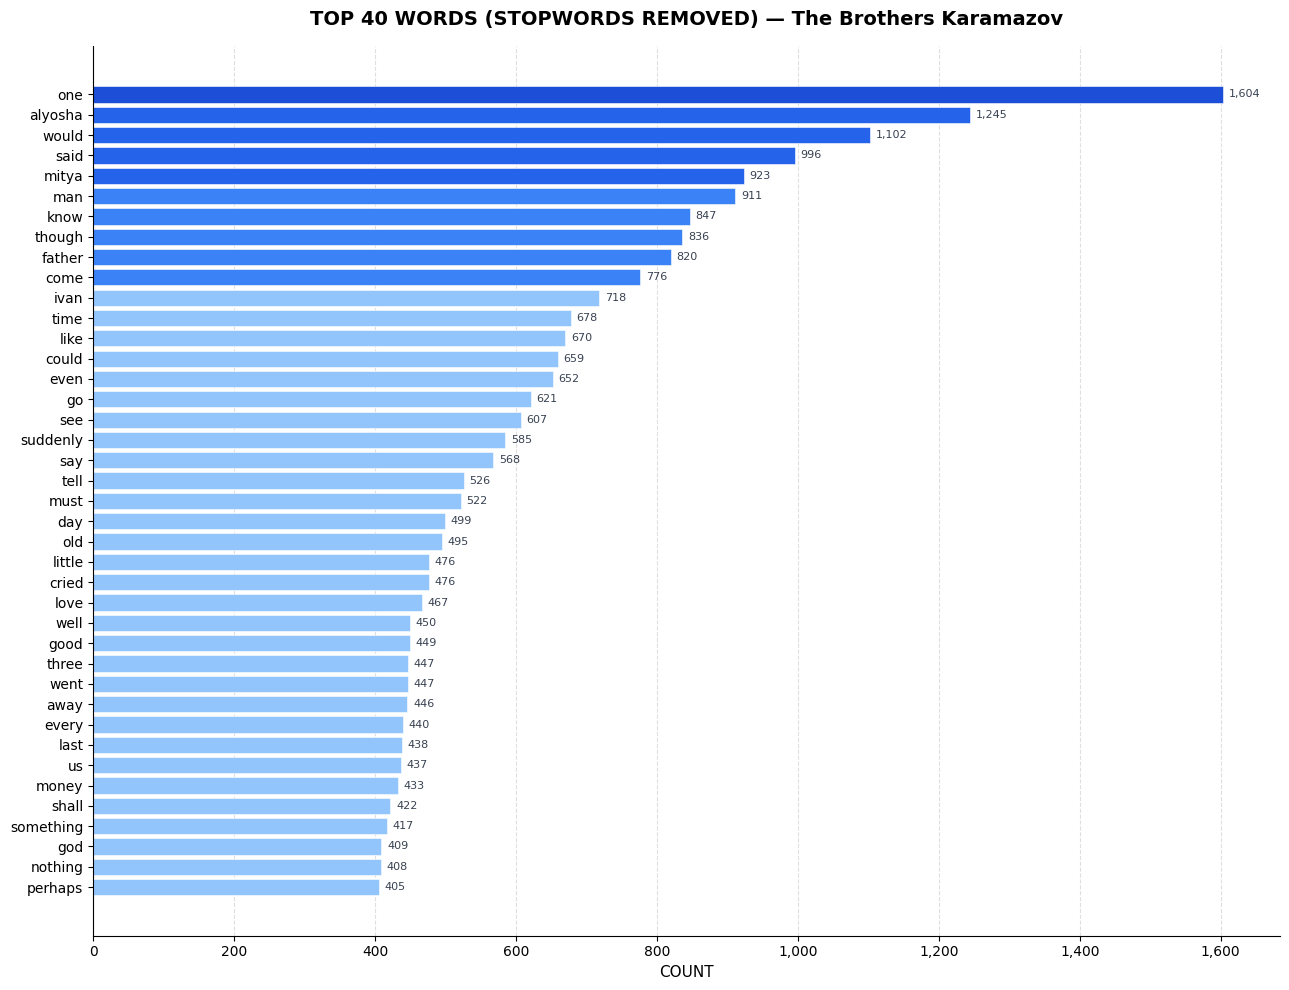





- **Phrase Patterns (N-grams)** (WILL WORK ON IT MONDAY)





**Unigrams**

Description: Since unigrams are essentially word counts 


**Unigram Table**

| Rank| Unigram | Count |
|---|---|---|
| 1 | one |  1,604|
| 2 | alyosha |1,245|
| 3 | would | 1,102|
| 4 | said | 996 | 
| 5 | mitya |  923|
| 6 | man |911|
| 7 | know | 847|
| 8 | though | 836 | 
| 9 | father |  820|
| 10 | come |776|
| 11 | ivan | 718|
| 12 | time | 678 | 
| 13 | like | 670 | 
| 14 | could | 659|
| 15 | even |652|
| 16 | go | 621|
| 17 | see | 607 | 
| 18 | suddenly |  585|
| 19 | say |568|
| 20 | tell | 526|
| 21 | must |  522|
| 22 | day |499|
| 23 | old | 495|
| 24 | little | 476 | 
| 25 | cried |  476|
| 26 | love |467|
| 27 | well | 450|
| 28 | good | 449 | 
| 29 | three |  447|
| 30 | went |447|
| 31 | away | 446|
| 32 | every | 440 | 
| 33 | last | 438 | 
| 34 | us | 437|
| 35 | money |433|
| 36 | shall | 422|
| 37 | something | 417 | 
| 38 | good |  409|
| 39 | nothing |408|
| 40 | perhaps | 405|

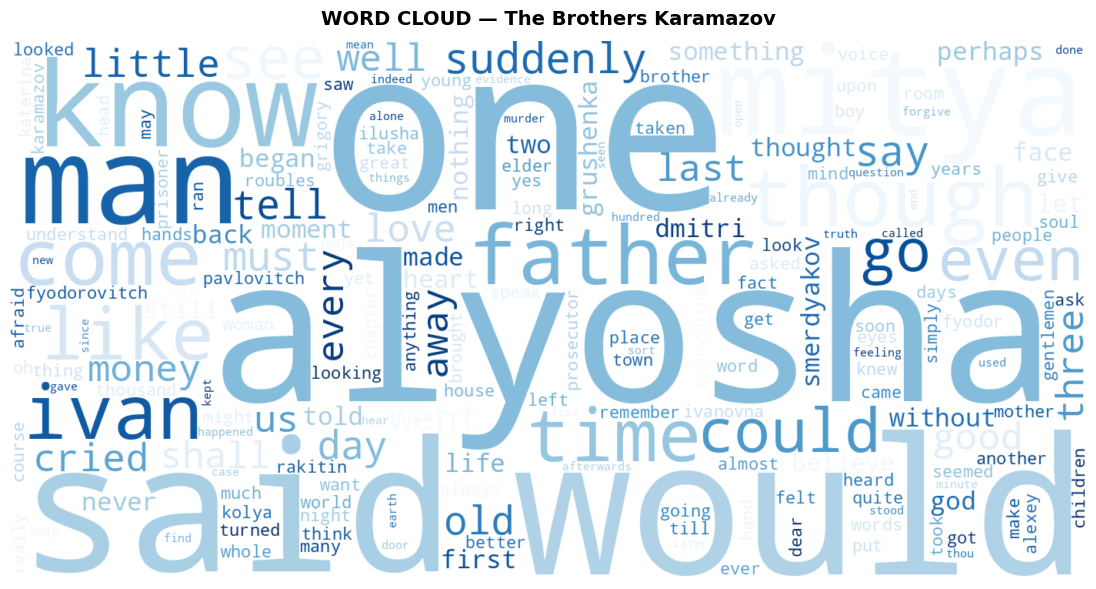

**Bigrams**

Description: 


**Bigram Table**

| Rank| Trigram | Count |
|---|---|---|
| 1 | fyodor pavlovitch |  300|
| 2 | every one |219|
| 3 | old man | 207|
| 4 | katerina ivanovna | 199 | 
| 5 | three thousand |  175|
| 6 | dmitri fyodorovitch |170|
| 7 | alexey fyodorovitch | 113|
| 8 | nikolay parfenovitch | 103 | 
| 9 | father zossima |  97|
| 10 | madame hohlakov |93|
| 11 | pyotr ilyitch | 91|
| 12 | said alyosha | 88 | 
| 13 | young man | 84 | 
| 14 | mi sov | 79|
| 15 | pa ssy |73|
| 16 | father pa | 72|
| 17 | thousand roubles | 68 | 
| 18 | long time |  60|
| 19 | ivan fyodorovitch |59|
| 20 | come back | 58|

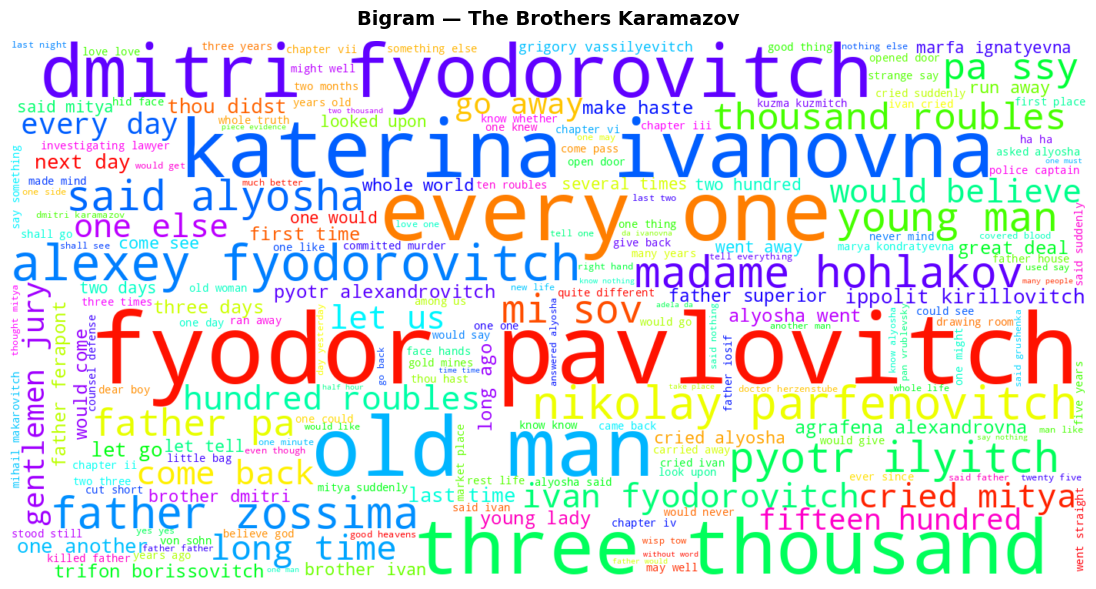

**Trigrams**

Description: klsdjfkljksdlkfjksdjflkjasd





**Trigram Table**

| Rank| Trigram | Count |
|---|---|---|
| 1 | father pa ssy |  72|
| 2 | three thousand roubles |45|
| 3 | adela da ivanovna | 14|
| 4 | two hundred roubles | 14 | 
| 5 | fifteen hundred roubles |  14|
| 6 | cried fyodor pavlovitch |13|
| 7 | hid face hands | 12|
| 8 | father fyodor pavlovitch | 11 | 
| 9 | hundred rouble notes |  11|
| 10 | dear alexey fyodorovitch |11|
| 11 | cried madame hohlakov | 9|
| 12 | fyodor pavlovitch karamazov | 8 | 
| 13 | like little child | 8 | 
| 14 | like fyodor pavlovitch | 8|
| 15 | tell whole truth |8|
| 16 | something quite different | 8|
| 17 | dear young lady | 8 | 
| 18 | agrafena alexandrovna come |  8|
| 19 | alexey fyodorvitch karamazov |7|
| 20 | pyotr alexandrovitch mi | 7|



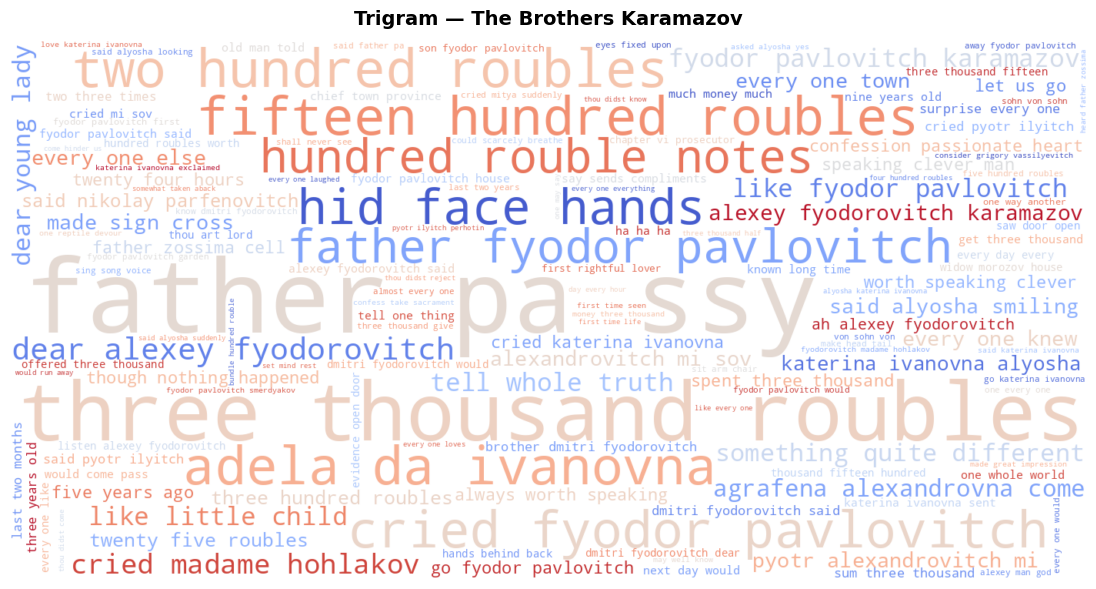

### Challenge: Sentence-Structure Metrics


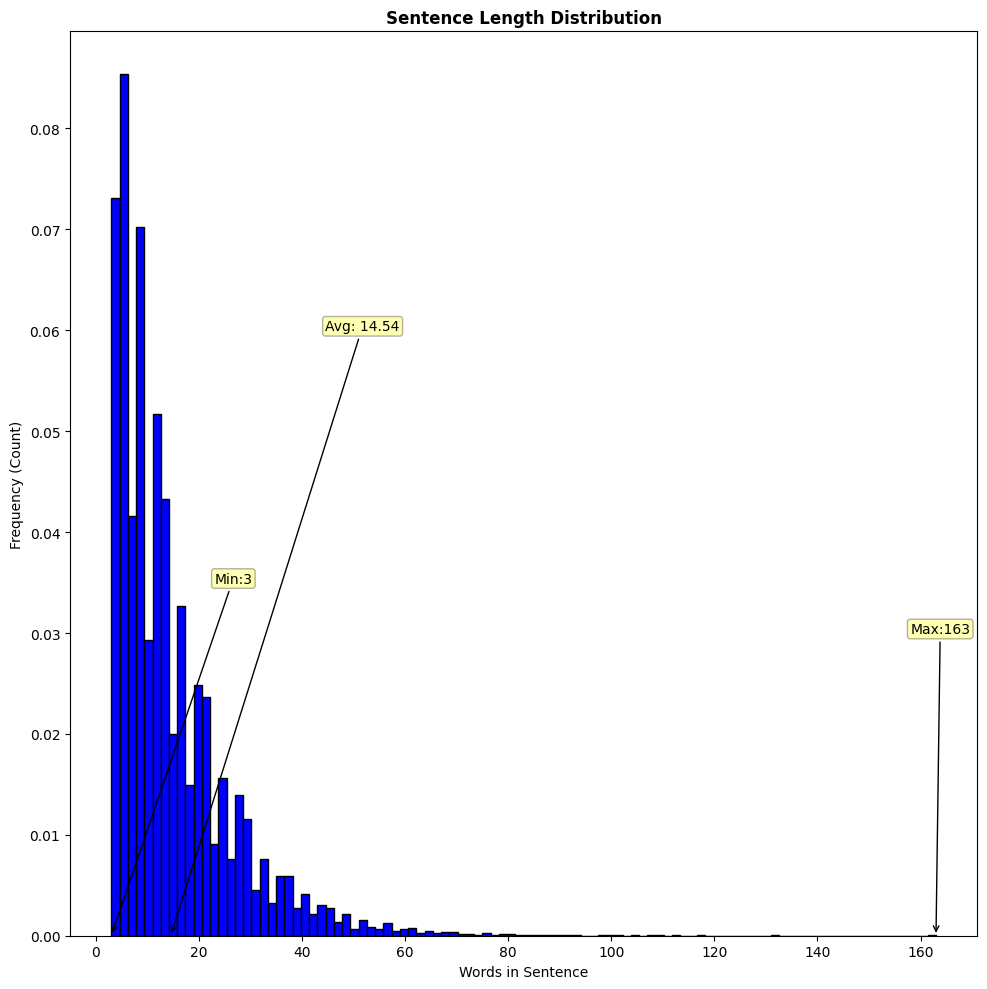